In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy
import matplotlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.mpl.ticker
import numpy as np
import importlib
import xarray as xr
import nc_time_axis
import cmocean
import cmocean.cm as cmo
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Polygon
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, BboxPatch, BboxConnector,\
    BboxConnectorPatch, zoomed_inset_axes, mark_inset
from matplotlib.transforms import (
    Bbox, TransformedBbox, blended_transform_factory)
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import shapely.geometry as sgeom
from matplotlib.lines import Line2D as Line
from matplotlib.patheffects import Stroke
import mpl_toolkits.axes_grid1.inset_locator as il
import cv2
import glob
import nc_time_axis
from eofs.xarray import Eof
import scipy.signal as sps
import scipy.linalg as spl
from scipy import stats
from matplotlib import gridspec
from scipy.signal import butter, lfilter
from functools import partial
from matplotlib.lines import Line2D

from statsmodels.tsa.seasonal import STL
import pandas as pd
from scipy.integrate import odeint
import _pickle as cPickle
import os,sys
from matplotlib.font_manager import FontProperties
import string
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap

import ultraplot as pplt

from matplotlib import patheffects

import pickle

In [2]:
mpl.rcParams['figure.dpi'] = 100

In [3]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

In [4]:
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

In [9]:
!ls variables/*.pickle

variables/prect_IND.pickle          variables/tauy_IND.pickle
variables/prect_LONLAT.pickle       variables/tauy_LONLAT.pickle
variables/prect_MEAN.pickle         variables/tauy_MEAN.pickle
variables/prect_PAC.pickle          variables/tauy_PAC.pickle
variables/prect_STD.pickle          variables/tauy_STD.pickle
variables/solin_IND.pickle          variables/temp_IND.pickle
variables/solin_LONLAT.pickle       variables/temp_LONLAT.pickle
variables/solin_MEAN.pickle         variables/temp_MEAN.pickle
variables/solin_PAC.pickle          variables/temp_PAC.pickle
variables/solin_STD.pickle          variables/temp_STD.pickle
variables/taux_IND.pickle           variables/thermocline_IND.pickle
variables/taux_LONLAT.pickle        variables/thermocline_LONLAT.pickle
variables/taux_MEAN.pickle          variables/thermocline_MEAN.pickle
variables/taux_PAC.pickle           variables/thermocline_PAC.pickle
variables/taux_STD.pickle           variables/thermocline_STD.pickle


In [5]:
directory = 'variables/derived_data/'

pickle_files = [f for f in os.listdir(directory) if f.endswith('.pickle')]

data_dict = {}

for filename in pickle_files:
    file_path = os.path.join(directory, filename)

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    key = os.path.splitext(filename)[0]
    data_dict[key] = data

for key, value in data_dict.items():
    print(f'Contents of {key}:')
    print(value)
    print('---' * 20)

Contents of temp_MEAN:
{'NINO34_max': {'NINO34': {'lonlat': <xarray.DataArray 'TS' (month: 12, lat: 16, lon: 77)> Size: 59kB
array([[[296.77606, 296.79904, 296.68182, ..., 295.58563, 295.39685,
         295.328  ],
        [298.29776, 298.34372, 298.253  , ..., 296.8268 , 296.88116,
         296.95248],
        [298.79944, 298.1795 , 298.55487, ..., 297.4114 , 297.63644,
         297.78107],
        ...,
        [286.1379 , 285.5987 , 286.8694 , ..., 294.55823, 294.23245,
         293.97336],
        [283.8841 , 282.75616, 289.72357, ..., 293.78488, 293.41217,
         293.09375],
        [280.24634, 286.54276, 283.35654, ..., 292.5793 , 292.3159 ,
         292.0423 ]],

       [[297.6698 , 297.68164, 297.5941 , ..., 296.58112, 296.4589 ,
         296.46286],
        [298.721  , 298.97098, 299.02963, ..., 297.6327 , 297.82614,
         297.96674],
        [298.80237, 298.25293, 299.03842, ..., 298.08054, 298.38904,
         298.47617],
...
        [290.53482, 290.38718, 291.9061 , ...,

In [16]:
#precipitation = sel_szn(precip_cmap,mon_list=[7])  # select month of precip to choose, yearly values obtained

def calculate_centroid_latitude(precipitation):
    # Select the latitude range of 20°N to 20°S
    if precipitation.lat.values[0] > 0:
        precipitation_lat_range = precipitation.sel(lat=slice(30, -30))
    else: 
        precipitation_lat_range = precipitation.sel(lat=slice(-30, 30))

    # Compute the latitude of the ITCZ centroid for each time step and longitude
    weights = np.cos(np.deg2rad(precipitation_lat_range.lat))
    weighted_precipitation = precipitation_lat_range * weights
    sum_over_latitude = weighted_precipitation.sum(dim='lat')

    # Compute the latitude corresponding to the centroid for each time step and longitude
    centroid_latitude = (precipitation_lat_range.lat * weighted_precipitation).sum(dim='lat') / sum_over_latitude
    
    # Create an xarray Dataset with the centroid_latitude, including the longitude dimension
    centroid_latitude_dataset = xr.Dataset(
        {'centroid_latitude': centroid_latitude},
        coords={'month':precipitation.month,'lon': precipitation.lon}
    )
    
    return centroid_latitude_dataset.centroid_latitude

In [124]:
#precipitation = sel_szn(precip_cmap,mon_list=[7])  # select month of precip to choose, yearly values obtained

def calculate_centroid_latitude(precipitation):
    # Select the latitude range of 30°N to 30°S
    if precipitation.lat.values[0] > 0:
        precipitation_lat_range = precipitation.sel(lat=slice(30, -30))
        fine_lat = np.arange(30, -30.1, 0.1)
    else: 
        precipitation_lat_range = precipitation.sel(lat=slice(-30, 30))
        fine_lat = np.arange(-30, 30.1, 0.1)

    fine_lon = np.arange(45, 285+1, 1)

    # Interpolate the latitude to a finer grid (0.1° steps)
    precipitation_interpolated = precipitation_lat_range.interp(lat=fine_lat,lon=fine_lon)

    max_precipitation_lat = precipitation_interpolated.idxmax(dim='lat')

    loc_ITCZ = np.zeros_like(precipitation_interpolated.lon)

    k = 0

    for i in precipitation_interpolated.lon.values:
        #print(i)
        
        #lat_range = precipitation_interpolated.sel(lat=slice(max_precipitation_lat.sel(lon=i,method='nearest').values, 31)).sel(lon=i,method='nearest')
        lat_range = precipitation_interpolated.sel(lat=slice(-31, 31)).sel(lon=i,method='nearest')

        weighted_precipitation = lat_range * lat_range.lat
        sum_over_latitude = weighted_precipitation.sum(dim='lat')
        sum_precipitation = lat_range.sum(dim='lat')

        # print(sum_precipitation)
        # print(sum_over_latitude)

        loc_ITCZ[k] = sum_over_latitude / sum_precipitation

        k += 1

    loc_ITCZ_dataset = xr.Dataset(
        {'loc_ITCZ': (['lon'], loc_ITCZ)},
        coords={'lon': precipitation_interpolated.lon}
    )
    
    return loc_ITCZ_dataset.loc_ITCZ

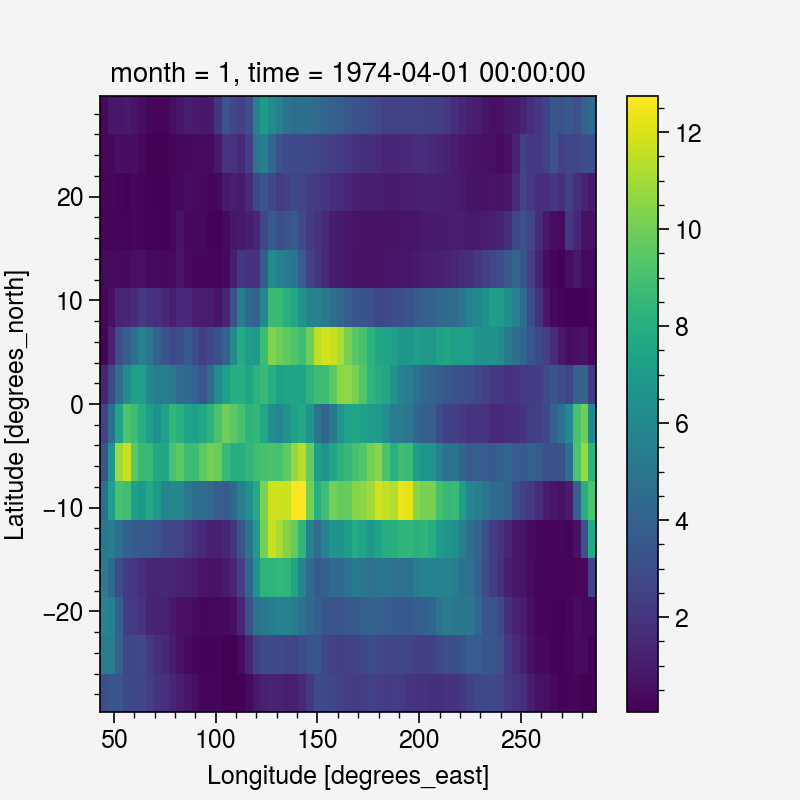

In [12]:
(data_dict['prect_LONLAT']['NINO34_max'].mn.isel(month=0)*8.64e+7 + data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7).plot()

In [8]:
data_dict['prect_LONLAT']['NINO34_max']

<xarray.Dataset> Size: 63kB
Dimensions:  (lon: 65, lat: 16, month: 4)
Coordinates:
  * lon      (lon) float64 520B 45.0 48.75 52.5 56.25 ... 277.5 281.2 285.0
  * lat      (lat) float64 128B -27.83 -24.12 -20.41 -16.7 ... 20.41 24.12 27.83
  * month    (month) int64 32B 1 2 3 4
    time     object 8B 1974-04-01 00:00:00
Data variables:
    mn       (month, lat, lon) float32 17kB 7.285e-09 8.431e-09 ... 1.138e-08
    mask     (month, lat, lon) int64 33kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    yr_mn    (lat, lon) float32 4kB 2.807e-08 3.164e-08 ... 4.262e-08 4.723e-08
    yr_mask  (lat, lon) int64 8kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0

In [94]:
data_dict['prect_LONLAT']['NINO34_max']['yr_mn'].lon

<xarray.DataArray 'lon' (lon: 65)> Size: 520B
array([ 45.  ,  48.75,  52.5 ,  56.25,  60.  ,  63.75,  67.5 ,  71.25,  75.  ,
        78.75,  82.5 ,  86.25,  90.  ,  93.75,  97.5 , 101.25, 105.  , 108.75,
       112.5 , 116.25, 120.  , 123.75, 127.5 , 131.25, 135.  , 138.75, 142.5 ,
       146.25, 150.  , 153.75, 157.5 , 161.25, 165.  , 168.75, 172.5 , 176.25,
       180.  , 183.75, 187.5 , 191.25, 195.  , 198.75, 202.5 , 206.25, 210.  ,
       213.75, 217.5 , 221.25, 225.  , 228.75, 232.5 , 236.25, 240.  , 243.75,
       247.5 , 251.25, 255.  , 258.75, 262.5 , 266.25, 270.  , 273.75, 277.5 ,
       281.25, 285.  ])
Coordinates:
  * lon      (lon) float64 520B 45.0 48.75 52.5 56.25 ... 277.5 281.2 285.0
    time     object 8B 1974-04-01 00:00:00
Attributes:
    name:               lon
    long_name:          Longitude
    units:              degrees_east
    axis:               X
    standard_name:      longitude
    coodinate_defines:  gridcell_center

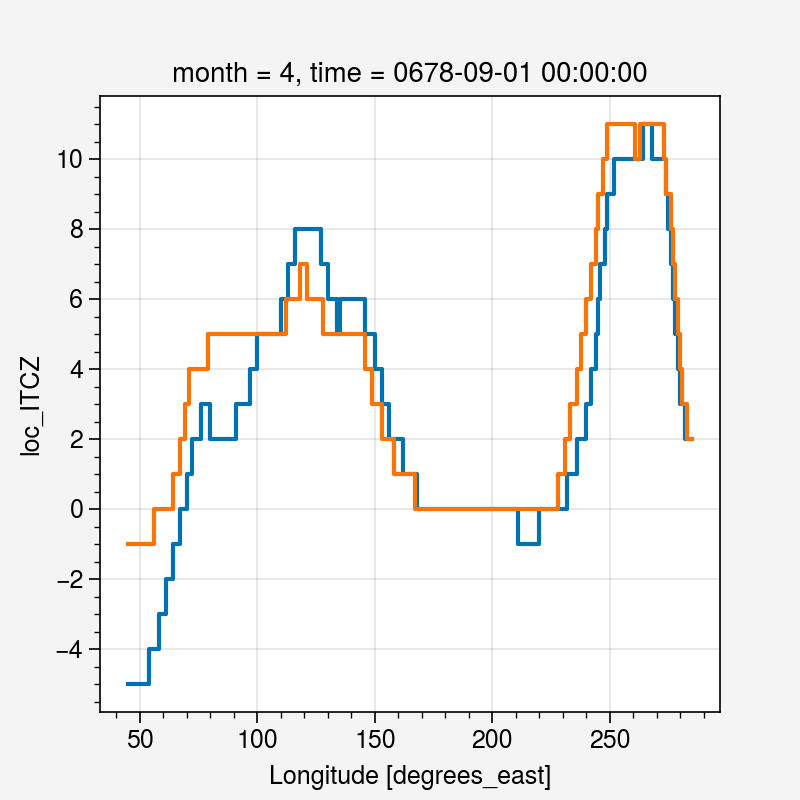

In [125]:
calculate_centroid_latitude((data_dict['prect_LONLAT']['NINO34_max'].mn.isel(month=3)*8.64e+7 + data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7)).plot.step()
calculate_centroid_latitude((data_dict['prect_LONLAT']['DMI_max'].mn.isel(month=3)*8.64e+7 + data_dict['prect_LONLAT']['DMI_max']['yr_mn']*8.64e+7)).plot.step(color='orange')

In [126]:
calculate_centroid_latitude((data_dict['prect_LONLAT']['DMI_max'].mn.isel(month=3)*8.64e+7 + data_dict['prect_LONLAT']['DMI_max']['yr_mn']*8.64e+7)).mean()

<xarray.DataArray 'loc_ITCZ' ()> Size: 8B
array(3.593361)
Coordinates:
    month    int64 8B 4
    time     object 8B 0678-09-01 00:00:00

In [127]:
calculate_centroid_latitude((data_dict['prect_LONLAT']['NINO34_max'].mn.isel(month=3)*8.64e+7 + data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7)).mean()


<xarray.DataArray 'loc_ITCZ' ()> Size: 8B
array(2.87966805)
Coordinates:
    month    int64 8B 4
    time     object 8B 1974-04-01 00:00:00

(-2.0, 5.0)

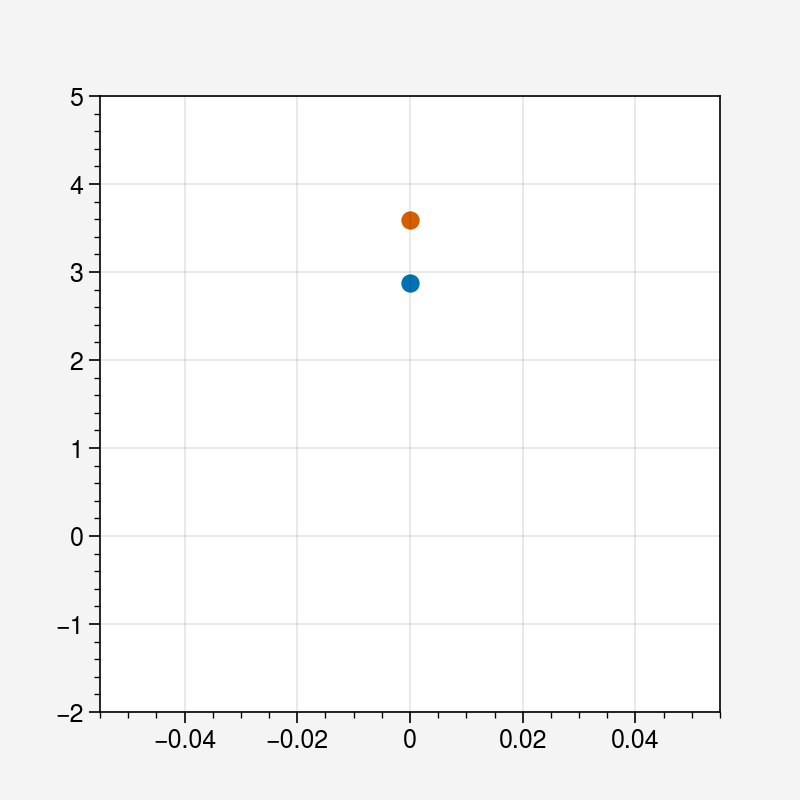

In [131]:
plt.scatter(0,calculate_centroid_latitude((data_dict['prect_LONLAT']['NINO34_max'].mn.isel(month=3)*8.64e+7 + data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7)).mean())
plt.scatter(0,calculate_centroid_latitude((data_dict['prect_LONLAT']['DMI_max'].mn.isel(month=3)*8.64e+7 + data_dict['prect_LONLAT']['DMI_max']['yr_mn']*8.64e+7)).mean())

plt.ylim(-2,5)

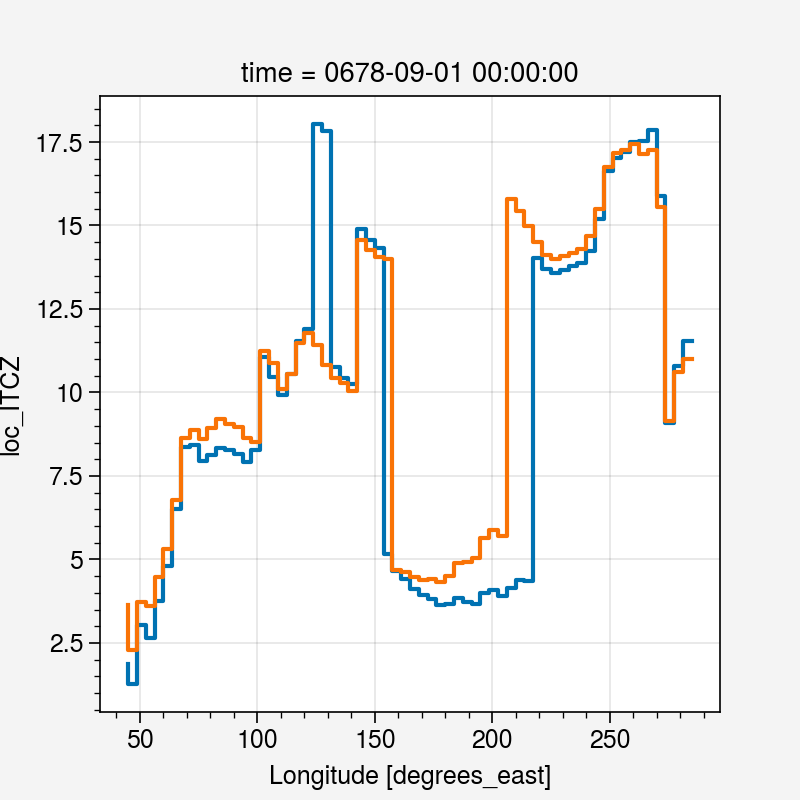

In [78]:
calculate_centroid_latitude(data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7).plot.step()
calculate_centroid_latitude(data_dict['prect_LONLAT']['DMI_max']['yr_mn']*8.64e+7).plot.step(color='orange')

<xarray.DataArray 'month' ()> Size: 8B
array(1)
Coordinates:
    month    int64 8B 1
    time     object 8B 1974-04-01 00:00:00


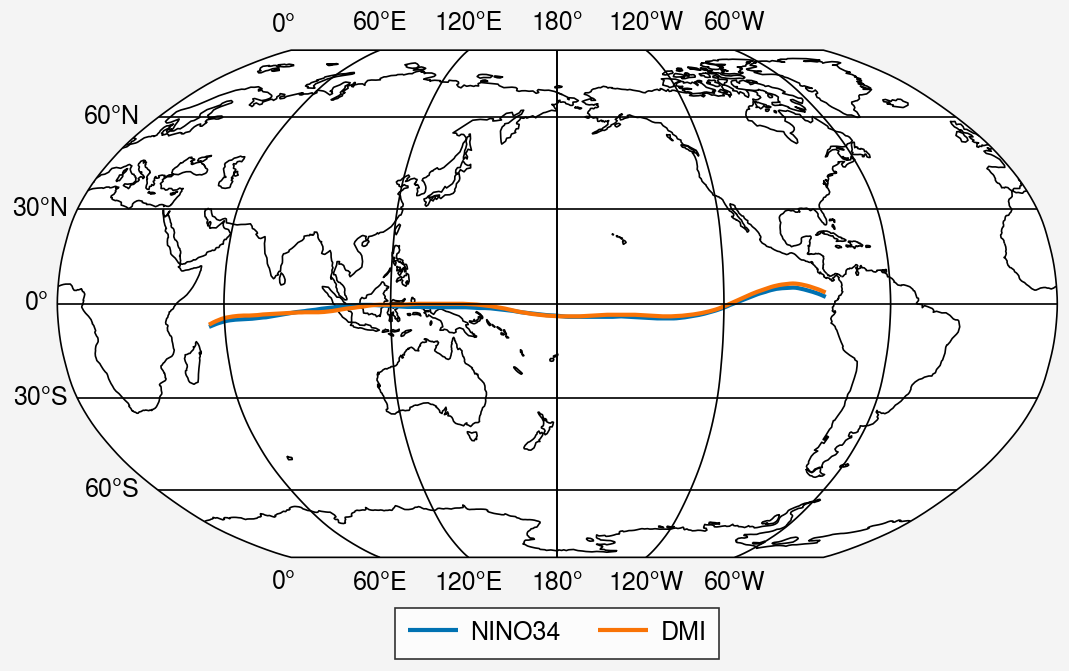


<xarray.DataArray 'month' ()> Size: 8B
array(2)
Coordinates:
    month    int64 8B 2
    time     object 8B 1974-04-01 00:00:00


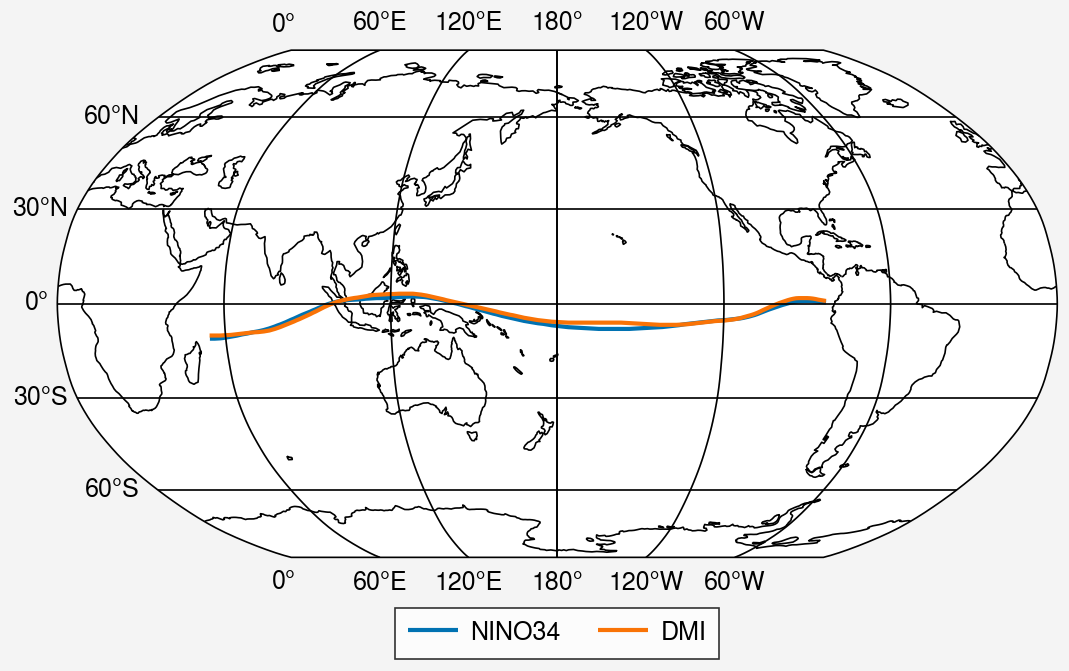


<xarray.DataArray 'month' ()> Size: 8B
array(3)
Coordinates:
    month    int64 8B 3
    time     object 8B 1974-04-01 00:00:00


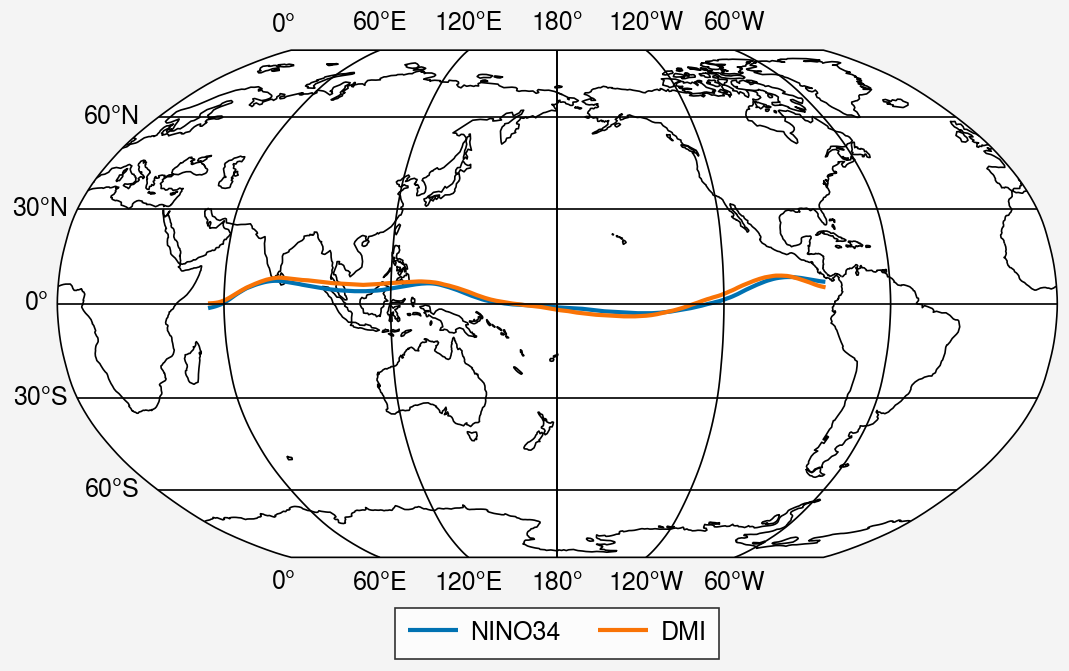


<xarray.DataArray 'month' ()> Size: 8B
array(4)
Coordinates:
    month    int64 8B 4
    time     object 8B 1974-04-01 00:00:00


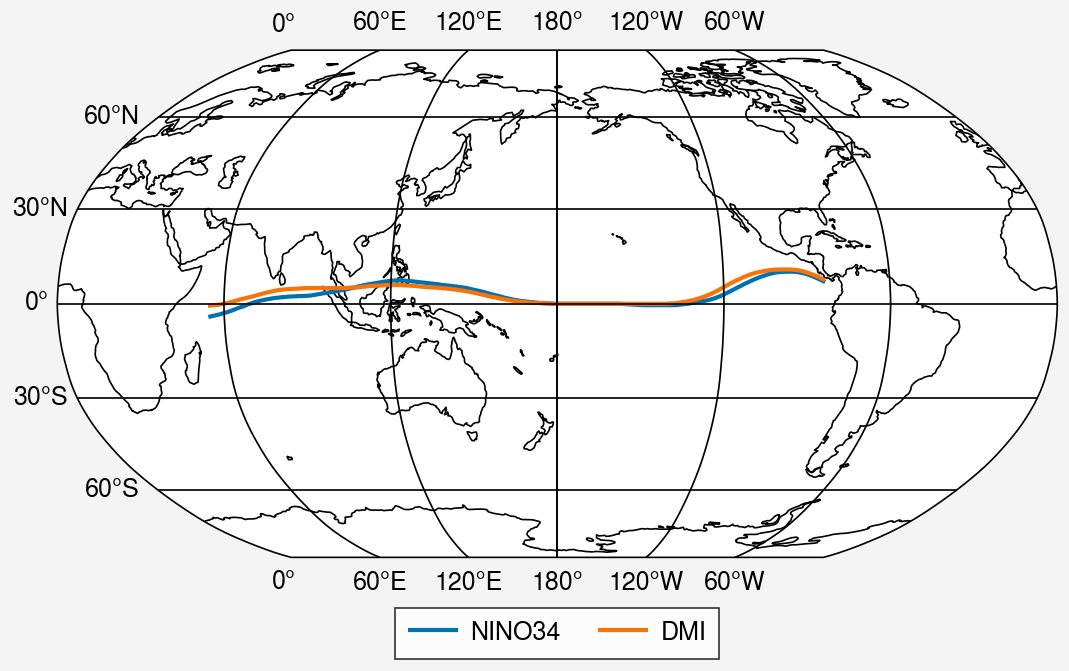

In [132]:
for i in data_dict['prect_LONLAT']['NINO34_max']['mn'].month:

    print(i)

    fig, ax = pplt.subplots(proj='robin', proj_kw={'lon_0': 180},refwidth=5)

    # itcz_nino34 = calculate_centroid_latitude(data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7)
    # itcz_dmi = calculate_centroid_latitude(data_dict['prect_LONLAT']['DMI_max']['yr_mn']*8.64e+7)

    itcz_nino34 = calculate_centroid_latitude(data_dict['prect_LONLAT']['NINO34_max']['yr_mn']*8.64e+7 + \
        data_dict['prect_LONLAT']['NINO34_max']['mn'].sel(month=i)*8.64e+7).rolling(lon=20, center=True).mean()
    itcz_dmi = calculate_centroid_latitude(data_dict['prect_LONLAT']['DMI_max']['yr_mn']*8.64e+7 + \
        data_dict['prect_LONLAT']['DMI_max']['mn'].sel(month=i)*8.64e+7).rolling(lon=20, center=True).mean()

    # Plot the ITCZ locations
    ax.plot(itcz_nino34.lon, itcz_nino34, label='NINO34', transform=ccrs.PlateCarree())
    ax.plot(itcz_dmi.lon, itcz_dmi, label='DMI', color='orange', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    ax.gridlines(draw_labels=True)

    # Add a legend
    ax.legend(loc='b')

    # Show the plot
    pplt.show()

    print('')

## mean-state seasonal cycles per perihelion composite
Companion to Fig. 3 with the diagnostics suggested by Reviewer 2: tropical insolation, Niño3.4 SST, basin-mean equatorial
zonal wind stress and zonal thermocline-proxy tilt for the Pacific (top row) and the Indian Ocean (bottom row), plus the
seasonality of Niño3.4 and DMI variability. Same sign conventions as Fig. 3 (negative wind stress = easterly; SSH proxy
× 0.01 as a depth in metres; tilt = west minus east). Shading is ±2 standard errors across the windows of each composite.

In [ ]:
# Mean seasonal cycles of the basin-scale quantities that set the Bjerknes feedback (insolation, SST,
# basin-mean equatorial zonal wind stress, zonal thermocline tilt from the SSH proxy) in the two perihelion
# composites of Fig. 3, together with the seasonality of Niño3.4 and DMI variability. Pacific/ENSO row first,
# Indian Ocean/IOD row second. Built from the calendar-adjusted box means (notebook 3) in 250-model-year
# windows; shading = ±2 standard errors across the ~200 windows of each composite.
boxes = xr.open_dataset('variables/derived_data/boxes_monthly_adjusted.nc')
vals = pickle.load(open('variables/vals_new.pkl', 'rb'))
params_ = xr.open_dataset('variables/orbital_params/pCESM.2Ma_orbPara.nc')
W = 250; NY = boxes.sizes['year']; nw = NY // W
centre_ka = -(NY - (np.arange(nw) * W + W / 2)) * 5 / 1000
lop_w = params_.interp(year=centre_ka)['longitude_of_perihelion'].values % 360
sel = {'NINO34_max': (lop_w >= vals.loc['Niño3.4', 'Range_high'][0]) & (lop_w <= vals.loc['Niño3.4', 'Range_high'][1]),
       'DMI_max':    (lop_w >= vals.loc['DMI', 'Range_high'][0]) & (lop_w <= vals.loc['DMI', 'Range_high'][1])}

# Figure: mean seasonal cycles per orbital configuration, styled as Fig. 1. Colour = orbital configuration
# (blue: windows of maximum Niño3.4 variability, orange: maximum DMI variability, as in the composites of the
# seasonal-cycle figure); shading = 95 % bootstrap CI of the composite mean; grey bands mark the growth season of the
# mode of each basin (ENSO: August–December; IOD: July–November).
C_CFG = {'NINO34_max': '#1f77b4', 'DMI_max': '#ff7f0e'}
LAB_CFG = {'NINO34_max': 'ENSO-favouring configuration (perihelion %.0f–%.0f°)' % tuple(vals.loc['Niño3.4', 'Range_high']),
           'DMI_max': 'IOD-favouring configuration (perihelion %.0f–%.0f°)' % tuple(vals.loc['DMI', 'Range_high'])}
rng = np.random.default_rng(1)
def boot_ci(m, n=10000):
    idx = rng.integers(0, m.shape[0], (n, m.shape[0])); bs = m[idx].mean(axis=1)
    return np.percentile(bs, 2.5, axis=0), np.percentile(bs, 97.5, axis=0)
def wclim(x): return x[:nw * W].reshape(nw, W, 12).mean(axis=1)
def wstd(x):  y = x[:nw * W].reshape(nw, W, 12); return (y - y.mean(axis=1, keepdims=True)).std(axis=1)
B = {k: boxes[k].values.astype(float) for k in boxes.data_vars}
Q = {'solin': wclim(B['SOLIN_tropics']), 'sig_n34': wstd(B['TS_nino34']), 'sig_dmi': wstd(B['TS_wio'] - B['TS_eio']),
     'sst_n34': wclim(B['TS_nino34']) - 273.15, 'taux_pac': -wclim(B['TAUX_eq_pac']), 'tilt_pac': (wclim(B['SSH_eq_wpac']) - wclim(B['SSH_eq_epac'])) * 0.01,
     'sst_dmi': wclim(B['TS_wio']) - wclim(B['TS_eio']), 'taux_io': -wclim(B['TAUX_eq_io']), 'tilt_io': (wclim(B['SSH_wio']) - wclim(B['SSH_eio'])) * 0.01}
# (key, title, ylabel, zero line, growth-season band)
ENSO_SZN, IOD_SZN = (8, 12), (7, 11)
panels = [('solin', 'Tropical insolation', 'TOA insolation [W m$^{-2}$]', None, None),
          ('sig_n34', 'Niño3.4 variability', r'$\sigma_{SST}$ [°C]', None, ENSO_SZN),
          ('sig_dmi', 'DMI variability', r'$\sigma_{SST}$ [°C]', None, IOD_SZN),
          ('sst_n34', 'Niño3.4 SST', 'SST [°C]', None, ENSO_SZN),
          ('taux_pac', 'Equatorial Pacific wind stress', r'$\tau_x$ [N m$^{-2}$]', 0, ENSO_SZN),
          ('tilt_pac', 'Pacific thermocline tilt', 'west $-$ east [m]', None, ENSO_SZN),
          ('sst_dmi', 'WIO $-$ EIO SST', 'SST [°C]', 0, IOD_SZN),
          ('taux_io', 'Equatorial Indian Ocean wind stress', r'$\tau_x$ [N m$^{-2}$]', 0, IOD_SZN),
          ('tilt_io', 'Indian Ocean thermocline tilt', 'WIO $-$ EIO [m]', 0, IOD_SZN)]
pplt.rc['font.size'] = 13
fig, axs = pplt.subplots([[1, 2, 3], [4, 5, 6], [7, 8, 9]], refwidth=2.9, refheight=2.3, share=False, wspace=4.5, hspace=5.5)
months = np.arange(1, 13); mn = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
handles = []
for ax, (q, title, ylabel, hline, szn) in zip(axs, panels):
    if szn is not None:
        ax.axvspan(szn[0] - 0.5, szn[1] + 0.5, color='0.94', linewidth=0, zorder=0)
    for key in ['NINO34_max', 'DMI_max']:
        m = Q[q][sel[key]]; mu = m.mean(axis=0); lo, hi = boot_ci(m)
        ax.fill_between(months, lo, hi, color=C_CFG[key], alpha=0.25, linewidth=0)
        h = ax.plot(months, mu, color=C_CFG[key], linewidth=2.2, label=LAB_CFG[key])
        if q == 'solin': handles.append(h)
    if hline is not None: ax.axhline(hline, linestyle='--', color='k', alpha=0.5, linewidth=0.8)
    ax.format(title=title, ylabel=ylabel, xlocator=months, xformatter=mn, xlim=(1, 12), xlabel='', xtickminor=False, ytickminor=False)
axs[1].text(10, axs[1].get_ylim()[0] + 0.01, 'ENSO growth season', ha='center', va='bottom', fontsize=8.5, color='0.35')
axs[2].text(9, axs[2].get_ylim()[0] + 0.01, 'IOD growth season', ha='center', va='bottom', fontsize=8.5, color='0.35')
fig.legend(handles, loc='b', ncol=2, frameon=False, fontsize=11)
axs.format(abc='a.', abcloc='ul', titleloc='c', titlesize=12, xtickdir='out', ytickdir='out', grid=False, ticklen=4.5, ylabelpad=5,
           leftlabels=['Forcing and variability', 'Pacific / ENSO', 'Indian Ocean / IOD'], leftlabelsize=12, leftlabelweight='bold')
plt.savefig('fig/szn_meanstate_perihelion.png', dpi=300, format='png', bbox_inches='tight', transparent=True)
plt.show()

### Fig. 4 — the seesaw
a) median amplitude of both modes versus longitude of perihelion with the two orbital configurations drawn with the Fig. 1 code (notebook 2); b) September–November difference map (relative SST, wind-stress streamlines) from the `*_LONLAT` composites of notebook 3 (season order DJF, MAM, JJA, SON), annotated with the causal chain. The same cell writes the SI figure with the SON and DJF difference maps.

In [ ]:
# Sun marker and orbit helpers, as used for Fig. 1 in notebook 2
from svgpath2mpl import parse_path
import matplotlib as mpl
sun_marker = parse_path("""M4671 12787 c-13 -6 -34 -25 -45 -40 l-21 -28 -8 -1457 c-9 -1611
-13 -1503 54 -1538 19 -9 45 -14 63 -11 17 3 181 88 364 190 l332 184 382 7
c275 5 391 11 413 20 39 17 65 56 65 99 0 26 -158 304 -726 1278 -446 764
-739 1257 -760 1277 -36 34 -72 41 -113 19z
M9603 12133 c-32 -19 -2044 -2008 -2075 -2053 -27 -39 -23 -94 10
-130 24 -28 62 -40 397 -136 l370 -106 280 -269 c283 -272 313 -295 367 -282
30 8 64 39 77 71 10 27 38 129 361 1362 89 338 206 785 261 994 120 455 122
462 103 497 -33 64 -92 84 -151 52z
M713 9750 c-62 -38 -78 -88 -45 -147 18 -32 2007 -2044 2052 -2075
39 -27 94 -23 130 10 27 24 41 63 137 398 l106 372 269 278 c271 282 294 312
281 366 -8 30 -39 64 -71 77 -15 6 -189 53 -387 105 -1934 508 -2375 623
-2411 629 -20 4 -41 0 -61 -13z
M6074 9589 c-1027 -99 -1976 -729 -2483 -1645 -183 -330 -311 -723
-366 -1124 -22 -160 -31 -532 -16 -699 63 -715 360 -1378 853 -1907 534 -574
1220 -915 2008 -999 157 -17 488 -19 643 -5 1039 99 1986 723 2496 1646 183
330 311 723 366 1124 22 160 31 532 16 699 -64 721 -364 1386 -865 1921 -528
562 -1215 901 -1996 985 -144 16 -515 18 -656 4z
M9764 8192 c-37 -23 -59 -71 -51 -111 3 -15 89 -177 190 -359 l184
-332 7 -382 c5 -275 11 -391 20 -413 17 -39 56 -65 99 -65 26 0 304 158 1278
726 796 464 1256 738 1278 761 29 31 33 40 28 75 -6 47 -37 84 -81 97 -18 5
-618 12 -1476 15 -1412 7 -1446 6 -1476 -12z
M1309 5544 c-796 -464 -1256 -738 -1278 -761 -29 -31 -33 -40 -28
-75 6 -47 37 -84 81 -97 18 -5 618 -12 1473 -16 1303 -6 1444 -5 1472 10 39
20 65 68 58 109 -3 17 -88 181 -190 364 l-184 332 -7 382 c-5 275 -11 391 -20
413 -17 39 -56 65 -99 65 -26 0 -304 -158 -1278 -726z
M9950 5263 c-27 -25 -40 -63 -136 -399 l-106 -370 -269 -280 c-272
-282 -295 -312 -282 -366 8 -30 39 -64 71 -77 27 -10 129 -38 1362 -361 338
-89 785 -206 994 -261 455 -120 462 -122 497 -103 64 33 84 92 52 151 -19 32
-2008 2044 -2053 2075 -39 27 -94 23 -130 -9z
M3845 3643 c-27 -7 -61 -39 -74 -71 -10 -27 -38 -129 -361 -1362 -89
-338 -206 -785 -261 -994 -120 -455 -122 -462 -103 -497 33 -64 92 -84 151
-51 32 18 2044 2007 2075 2052 27 39 23 94 -9 130 -25 27 -63 40 -399 136
l-371 106 -269 260 c-148 143 -278 266 -289 273 -25 16 -64 24 -90 18z
M8040 3072 c-19 -10 -174 -95 -345 -189 l-310 -171 -380 -7 c-273 -5
-388 -10 -410 -19 -39 -17 -65 -56 -65 -99 0 -26 158 -304 726 -1278 465 -797
738 -1256 761 -1278 31 -29 40 -33 75 -28 47 6 84 37 97 81 5 18 12 618 16
1473 7 1591 11 1484 -55 1518 -38 20 -68 19 -110 -3z""")

sun_marker.vertices -= sun_marker.vertices.mean(axis=0)
sun_marker = sun_marker.transformed(mpl.transforms.Affine2D().rotate_deg(180))
sun_marker = sun_marker.transformed(mpl.transforms.Affine2D().scale(-1,1))


angle = 0
# Function to calculate rays
def rays(t, e, a, b):
    t = t * np.pi / 180
    p = b ** 2.0 / a
    E = e / a
    r = p / (1 - E * np.cos(t))
    xr = r * np.cos(t)
    yr = r * np.sin(t)
    xrp = xr * np.cos(angle * np.pi / 180.0) - yr * np.sin(angle * np.pi / 180.0)
    yrp = xr * np.sin(angle * np.pi / 180.0) + yr * np.cos(angle * np.pi / 180.0)
    return xrp, yrp

# Function to add curved text outside the ellipse
def add_curved_text_outside(ax, text, size, offset, x_center, y_center, a, b, e, angle):
    a = a * 1.12
    b = b * 1.12

    for i, char in enumerate(text):
        char_angle = angle + i * offset
        char_x = x_center + rays(char_angle, e, a, b)[0]
        char_y = y_center + rays(char_angle, e, a, b)[1]
        ax.text(char_x, char_y, char, fontsize=size, ha='center', va='center')

# Function to add curved text inside the ellipse
def add_curved_text_inside(ax, text, size, offset, x_center, y_center, a, b, e, angle, color='k'):
    a = a * 0.9
    b = b * 0.9

    for i, char in enumerate(text):
        char_angle = angle + i * offset
        char_x = x_center + rays(char_angle, e, a, b)[0]
        char_y = y_center + rays(char_angle, e, a, b)[1]
        ax.text(char_x, char_y, char, fontsize=size, ha='center', va='center', color=color, zorder=500)
        
def weighted_angle(std_values,std_variability):
        
    weighted_sum_sin = np.sum(np.sin(np.deg2rad(std_values)) * std_variability) / np.sum(std_variability)
    weighted_sum_cos = np.sum(np.cos(np.deg2rad(std_values)) * std_variability) / np.sum(std_variability)

    if weighted_sum_sin >= 0:
        weighted_angle = np.arctan2(weighted_sum_sin, weighted_sum_cos)
    else:
        weighted_angle = np.arctan2(weighted_sum_sin, weighted_sum_cos) + 2 * np.pi
        
    return np.rad2deg(weighted_angle)

def plot_hatching_pattern(ax, xf, yf, e, a, b, mean_min_angle_high, mean_max_angle_high, color, num_points=100,alpha=.1):
    hatch_points_x = [xf[0]]
    hatch_points_y = [yf[0]]

    hatch_points_x2 = [xf[0]]
    hatch_points_y2 = [yf[0]]

    for i in range(num_points):
        if (mean_max_angle_high <= 70) and (mean_min_angle_high >= 300):
            if mean_max_angle_high <= 70:
                angle_interp = mean_max_angle_high + (i / (num_points - 1)) * (0 - mean_max_angle_high)
                x_interp = xf[0] + rays(angle_interp, e, a, b)[0]
                y_interp = yf[0] + rays(angle_interp, e, a, b)[1]
                hatch_points_x.append(x_interp)
                hatch_points_y.append(y_interp)

            if mean_min_angle_high >= 300:
                angle_interp2 = mean_min_angle_high + (i / (num_points - 1)) * (360 - mean_min_angle_high)
                x_interp2 = xf[0] + rays(angle_interp2, e, a, b)[0]
                y_interp2 = yf[0] + rays(angle_interp2, e, a, b)[1]
                hatch_points_x2.append(x_interp2)
                hatch_points_y2.append(y_interp2)
        else:
            
            angle_interp = mean_min_angle_high + (i / (num_points - 1)) * (mean_max_angle_high - mean_min_angle_high)
            x_interp = xf[0] + rays(angle_interp, e, a, b)[0]
            y_interp = yf[0] + rays(angle_interp, e, a, b)[1]
            hatch_points_x.append(x_interp)
            hatch_points_y.append(y_interp)

    if (mean_max_angle_high <= 30) and (mean_min_angle_high >= 330):
        hatch_points_x2.append(xf[0])
        hatch_points_y2.append(yf[0])
        hatch_points_x.append(xf[0])
        hatch_points_y.append(yf[0])
        ax.fill(hatch_points_x, hatch_points_y, facecolor=color, alpha=alpha)
        ax.fill(hatch_points_x2, hatch_points_y2, facecolor=color, alpha=alpha)
    else:
        hatch_points_x.append(xf[0])
        hatch_points_y.append(yf[0])
        ax.fill(hatch_points_x, hatch_points_y, facecolor=color, alpha=alpha)



# Figure 4 — the seesaw: a) median amplitude of both modes over the precession cycle with the two orbital
# configurations drawn as in Fig. 1 (same ellipse code) above their perihelion ranges; b) the September–November
# difference between the two configurations (SST shading, wind-stress streamlines) annotated with the causal chain.
# Seasonal composites (notebook 3, *_LONLAT pickles) are stored in the order DJF, MAM, JJA, SON.
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.patches import Ellipse, Rectangle
import matplotlib as mpl
angle = 0
SEASON = {'DJF': 1, 'MAM': 2, 'JJA': 3, 'SON': 4}
C = {'NINO34_max': '#1f77b4', 'DMI_max': '#ff7f0e'}; CN34, CDMI = '#2166ac', '#b2182b'
TINT = {'NINO34_max': '#eef4fb', 'DMI_max': '#fff4e8'}
LAB = {'NINO34_max': 'ENSO-favouring configuration', 'DMI_max': 'IOD-favouring configuration'}
def wstd_ann(x): y = x[:nw * W].reshape(nw, W, 12).mean(axis=2); return y.std(axis=1)
B = {k: boxes[k].values.astype(float) for k in boxes.data_vars}
sig34, sigdmi = wstd_ann(B['TS_nino34']), wstd_ann(B['TS_wio'] - B['TS_eio'])
lonlat = {v: pickle.load(open(f'variables/derived_data/{v}_LONLAT.pickle', 'rb')) for v in ['temp', 'taux', 'tauy']}
def field(v, key, season):  # absolute seasonal mean = seasonal anomaly + annual mean
    d = lonlat[v][key]; return d.mn.sel(month=SEASON[season]) + d.yr_mn
def diff(v, season, a='DMI_max', b='NINO34_max'):
    d = field(v, a, season) - field(v, b, season)
    if v == 'temp':                                   # relative SST: remove the area-weighted tropical-mean difference
        w = np.cos(np.deg2rad(d.lat)); d = d - d.weighted(w).mean(('lat', 'lon'))
    return d

def orbit(ax, key, name, fs=6.0):
    ra, rp = 4.5, 0.5; a = (ra + rp) / 2; e = (ra - rp) / (ra + rp); b = np.sqrt(a**2 - e**2); x = y = 3
    p_ = b**2 / a; E = e / a
    ax.add_artist(Ellipse((x, y), 2 * a, 2 * b, facecolor='w', edgecolor='k', linewidth=0.9))
    xf = [x - e, x + e]; yf = [y, y]
    ax.plot(xf[0], yf[0], marker=sun_marker, color='y', markeredgecolor='w', markeredgewidth=0.8, markersize=20, zorder=150, linestyle='none')
    for t in [0, 180]:
        xr_, yr_ = rays(t, e, a, b); ax.plot([xf[0], xf[0] + xr_], [yf[0], yf[0] + yr_], '--k', linewidth=0.7)
    add_curved_text_outside(ax, 'Perihelion'[::-1], fs - 0.7, 8, xf[0] - 0.05, yf[0], a, b, e, 180 - 40)
    add_curved_text_outside(ax, 'Aphelion', fs - 0.7, 6, xf[0] + 0.05, yf[0], a, b, e, 0 - 20)
    lop = float(vals.loc[name, 'Weighted_angle_95']); rng_ = [float(v) for v in vals.loc[name, 'Range_high']]
    plot_hatching_pattern(ax, xf, yf, e, a, b, rng_[0], rng_[1], 'r', alpha=0.15)
    for t, lab in zip([lop, lop + 90, lop + 180, lop + 270], ['Vernal\nequinox', 'Winter\nsolstice', 'Autumnal\nequinox', 'Summer\nsolstice']):
        xr_, yr_ = rays(t, e, a, b); ax.plot([xf[0], xf[0] + xr_], [yf[0], yf[0] + yr_], '-', color='r', linewidth=1.0, zorder=100)
        r = p_ / (1 - E * np.cos(np.deg2rad(t))) + 1.35
        ax.text(xf[0] + r * np.cos(np.deg2rad(t)), yf[0] + r * np.sin(np.deg2rad(t)), lab, color='firebrick', fontsize=fs, ha='center', va='center', fontweight='bold')
    xe, ye = rays(180, e, a, b); ax.plot(xf[0] + xe, yf[0] + ye, 'o', color='k', markersize=6, zorder=200)
    ax.set_xlim(-1.8, 2 * x + 1.8); ax.set_ylim(-1.0, 2 * y + 1.0); ax.invert_yaxis(); ax.set_aspect('equal'); ax.axis('off')

def causal_map(ax, season='SON', a='DMI_max', b='NINO34_max', annotate=True, title=None):
    dSST = diff('temp', season, a, b); dU = -diff('taux', season, a, b); dV = -diff('tauy', season, a, b)   # CAM stress sign → wind
    lon, lat = dSST.lon.values, dSST.lat.values
    cf = ax.contourf(lon, lat, dSST.values, levels=np.arange(-2, 2.01, 0.25), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
    spd = np.hypot(dU.values, dV.values)
    ax.streamplot(lon, lat, dU.values, dV.values, transform=ccrs.PlateCarree(), density=0.85, color='0.2', linewidth=0.4 + 35 * spd, arrowsize=0.8, arrowstyle='-|>', zorder=5)
    ax.add_feature(cfeature.LAND, facecolor='0.78', zorder=3); ax.coastlines(linewidth=0.4, zorder=4)
    for (x0, x1, y0, y1, col) in [(190, 240, -5, 5, C['NINO34_max']), (50, 70, -10, 10, C['DMI_max']), (90, 110, -10, 0, C['DMI_max'])]:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor='none', edgecolor=col, linewidth=1.6, transform=ccrs.PlateCarree(), zorder=6))
    ax.set_extent([45, 285, -28, 28], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0, xlocs=[60, 90, 120, 150, 180, 210, 240, 270], ylocs=[-20, 0, 20]); gl.top_labels = gl.right_labels = False; gl.xlabel_style = gl.ylabel_style = {'size': 7}
    if title: ax.set_title(title, fontsize=8.5, pad=3)
    if annotate:
        kw = dict(fontsize=7, ha='center', va='center', zorder=10, transform=ccrs.PlateCarree(), fontweight='bold')
        ax.text(60, 13.5, 'WIO', color=C['DMI_max'], **kw); ax.text(100, 3, 'EIO', color=C['DMI_max'], **kw); ax.text(215, 8.5, 'Niño3.4', color=C['NINO34_max'], **kw)
        ax.text(78, -20, 'equatorial easterlies,\nwarm west / cool east', color='k', fontsize=6.8, ha='center', va='center', zorder=10, transform=ccrs.PlateCarree(),
                bbox=dict(boxstyle='round,pad=0.25', facecolor='w', edgecolor=C['DMI_max'], linewidth=0.8))
        ax.text(225, -20, 'stronger trades,\ncooler eastern Pacific', color='k', fontsize=6.8, ha='center', va='center', zorder=10, transform=ccrs.PlateCarree(),
                bbox=dict(boxstyle='round,pad=0.25', facecolor='w', edgecolor=C['NINO34_max'], linewidth=0.8))
    return cf

with mpl.rc_context({'font.family': 'sans-serif', 'font.sans-serif': ['TeX Gyre Heros', 'Arial', 'DejaVu Sans'], 'font.size': 9,
                     'axes.grid': False, 'xtick.minor.visible': False, 'ytick.minor.visible': False, 'axes.linewidth': 0.8,
                     'xtick.direction': 'out', 'ytick.direction': 'out', 'axes.titleweight': 'bold'}):
    fig = plt.figure(figsize=(7.2, 10.4)); fig.patch.set_alpha(0)
    # ---- a) amplitude vs longitude of perihelion, with the orbits above their ranges --------------------------
    axa = fig.add_axes([0.10, 0.60, 0.80, 0.20])
    bins = np.arange(0, 361, 15); cen = bins[:-1] + 7.5
    med34 = [np.nanmedian(sig34[(lop_w >= b) & (lop_w < b + 15)]) for b in bins[:-1]]
    meddmi = [np.nanmedian(sigdmi[(lop_w >= b) & (lop_w < b + 15)]) for b in bins[:-1]]
    ranges = {k: [float(v) for v in vals.loc['Niño3.4' if k == 'NINO34_max' else 'DMI', 'Range_high']] for k in C}
    for key, tint in [('NINO34_max', '#d2e3f3'), ('DMI_max', '#ffe3c7')]:
        r = ranges[key]; axa.add_patch(Rectangle((r[0], 0), r[1] - r[0], 1, transform=axa.get_xaxis_transform(), facecolor=tint, edgecolor='none', zorder=0))
    axa.plot(cen, med34, color=CN34, linewidth=2.2); axa2 = axa.twinx(); axa2.plot(cen, meddmi, color=CDMI, linewidth=2.2)
    axa.axvline(abs(280.3 - 180), color='0.45', linewidth=1.5); axa.text(abs(280.3 - 180) + 3, 0.303, 'today', fontsize=7.5, color='0.45', va='bottom')
    axa.set_xlim(0, 360); axa.set_xticks([0, 90, 180, 270, 360]); axa.set_ylim(0.30, 0.38); axa2.set_ylim(0.20, 0.33)
    axa.set_xlabel('λ, longitude of the perihelion [°]', fontsize=8.5); axa.set_ylabel('Niño3.4 σ$_{SST}$ [°C]', color=CN34, fontsize=8.5); axa2.set_ylabel('DMI σ$_{SST}$ [°C]', color=CDMI, fontsize=8.5)
    for a_ in (axa, axa2): a_.tick_params(labelsize=7.5); a_.spines['top'].set_visible(False)
    axa.spines['left'].set_color(CN34); axa2.spines['right'].set_color(CDMI); axa.tick_params(axis='y', colors=CN34); axa2.tick_params(axis='y', colors=CDMI)
    fig.text(0.02, 0.985, 'a.', fontsize=11, fontweight='bold', ha='left', va='bottom')
    fig.text(0.5, 0.985, 'Amplitude of the two modes over the precession cycle: anti-phased (coherence 0.66, phase 169°)', fontsize=8.5, fontweight='bold', ha='center', va='bottom')
    for key, name in [('NINO34_max', 'Niño3.4'), ('DMI_max', 'DMI')]:
        r = ranges[key]; x0 = 0.10 + r[0] / 360 * 0.80; x1 = 0.10 + r[1] / 360 * 0.80; xc = (x0 + x1) / 2
        ow, oh = 0.30, 0.14; ox0, oy0 = xc - ow / 2, 0.835
        axo = fig.add_axes([ox0, oy0, ow, oh]); orbit(axo, key, name)
        fig.text(xc, 0.828, f'{LAB[key]}\n(perihelion {r[0]:.0f}–{r[1]:.0f}°)', color=C[key], fontsize=7, ha='center', va='top', fontweight='bold')
        # connectors from the shaded range (top of panel a) to the orbit box, as with an inset indicator
        ytop = 0.60 + 0.20                                              # top of panel a in figure coordinates
        for xa, xb in [(x0, ox0 + 0.02), (x1, ox0 + ow - 0.02)]:
            fig.add_artist(mpl.lines.Line2D([xa, xb], [ytop, oy0 - 0.005], transform=fig.transFigure, color=C[key], linewidth=0.8, alpha=0.8))
        fig.add_artist(mpl.patches.Rectangle((x0, ytop), x1 - x0, 0.004, transform=fig.transFigure, facecolor=C[key], edgecolor='none'))
    # ---- b) causal map -------------------------------------------------------------------------------------------
    axb = fig.add_axes([0.07, 0.345, 0.86, 0.21], projection=ccrs.PlateCarree(central_longitude=165))
    cf = causal_map(axb, 'SON', title='September–November: IOD-favouring minus ENSO-favouring configuration')
    axb.text(-0.06, 1.05, 'b.', transform=axb.transAxes, fontsize=11, fontweight='bold')
    cax = fig.add_axes([0.94, 0.36, 0.012, 0.18]); cb = fig.colorbar(cf, cax=cax, ticks=[-2, -1, 0, 1, 2]); cb.set_label('relative SST [°C]', fontsize=7.5); cb.ax.tick_params(labelsize=7, length=2)
    # ---- c) causal chain --------------------------------------------------------------------------------------------
    axc = fig.add_axes([0.04, 0.03, 0.92, 0.27]); axc.set_xlim(0, 1); axc.set_ylim(0, 1); axc.axis('off')
    axc.text(0.0, 1.03, 'c.', transform=axc.transAxes, fontsize=11, fontweight='bold')
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
    chains = {
        'NINO34_max': ['Perihelion in boreal winter (λ ≈ 100°, as today)',
                       'Tropical insolation surplus in December–March,\ndeficit in June–July',
                       'Pacific, August–December: weak trades,\nflat thermocline, warm Niño3.4',
                       'Stronger Bjerknes feedback\nin the ENSO growth season',
                       'ENSO amplitude high\nIOD amplitude low, autumn phase locking lost'],
        'DMI_max':    ['Perihelion in boreal summer (λ ≈ 280°)',
                       'Tropical insolation surplus in June–September',
                       'Indian Ocean, July–November: equatorial easterlies,\nstrong thermocline tilt, cool eastern Indian Ocean',
                       'Stronger Bjerknes feedback\nin the IOD growth season',
                       'IOD amplitude high, locked to autumn\nENSO amplitude low (strong trades, cool east)']}
    ys = [0.90, 0.70, 0.50, 0.30, 0.09]; bw, bh = 0.44, 0.12
    for key, xc_ in [('NINO34_max', 0.25), ('DMI_max', 0.75)]:
        for i, (y, txt) in enumerate(zip(ys, chains[key])):
            head = i == 0; last = i == len(ys) - 1
            axc.add_patch(FancyBboxPatch((xc_ - bw/2, y - bh/2), bw, bh, boxstyle='round,pad=0.01,rounding_size=0.02',
                                         facecolor=('w' if not (head or last) else TINT.get(key, 'w')) if 'TINT' in globals() else 'w',
                                         edgecolor=C[key], linewidth=1.4 if (head or last) else 0.9))
            axc.text(xc_, y, txt, ha='center', va='center', fontsize=7.2, color='k', fontweight='bold' if (head or last) else 'normal', linespacing=1.25)
            if not last:
                axc.add_patch(FancyArrowPatch((xc_, y - bh/2 - 0.005), (xc_, ys[i+1] + bh/2 + 0.005), arrowstyle='-|>', mutation_scale=10, color=C[key], linewidth=1.2))
    axc.text(0.25, 1.0, 'ENSO-favouring configuration', ha='center', va='center', fontsize=8, color=C['NINO34_max'], fontweight='bold')
    axc.text(0.75, 1.0, 'IOD-favouring configuration', ha='center', va='center', fontsize=8, color=C['DMI_max'], fontweight='bold')
    plt.savefig('fig/schematic_seesaw.png', dpi=300, format='png', bbox_inches='tight', transparent=True)
    plt.show()

# ---- Supplementary figure: the two seasonal difference maps without annotations ---------------------------------
with mpl.rc_context({'font.family': 'sans-serif', 'font.sans-serif': ['TeX Gyre Heros', 'Arial', 'DejaVu Sans'], 'font.size': 9, 'axes.grid': False, 'axes.titleweight': 'bold'}):
    fig = plt.figure(figsize=(7.2, 6.0)); fig.patch.set_alpha(0)
    ax1 = fig.add_axes([0.07, 0.55, 0.86, 0.38], projection=ccrs.PlateCarree(central_longitude=165))
    cf = causal_map(ax1, 'SON', 'DMI_max', 'NINO34_max', annotate=False, title='a. September–November: IOD-favouring minus ENSO-favouring configuration')
    ax2 = fig.add_axes([0.07, 0.08, 0.86, 0.38], projection=ccrs.PlateCarree(central_longitude=165))
    cf = causal_map(ax2, 'DJF', 'NINO34_max', 'DMI_max', annotate=False, title='b. December–February: ENSO-favouring minus IOD-favouring configuration')
    cax = fig.add_axes([0.94, 0.25, 0.012, 0.5]); cb = fig.colorbar(cf, cax=cax, ticks=[-2, -1, 0, 1, 2]); cb.set_label('relative SST [°C]', fontsize=8); cb.ax.tick_params(labelsize=7, length=2)
    plt.savefig('fig/szn_diff_maps_si.png', dpi=300, format='png', bbox_inches='tight', transparent=True)
    plt.show()